# 학생=1.0 고정, EMA를 $1/(1-m)$ step 돌리면 교사 값은?

DINO의 교사는 학생 파라미터의 **지수 이동평균(EMA)** 으로만 갱신된다.

$$
\theta_t \leftarrow m\,\theta_t + (1-m)\,\theta_s,
\qquad m: 0.996 \nearrow 1.0
$$

`main_dino.py` 의 실제 코드는 한 줄이다.

```python
param_k.data.mul_(m).add_((1 - m) * param_q.detach().data)
```

이 노트북은 **교사 0, 학생 1.0 고정** 이라는 계단 입력을 넣고
정확히 $T = 1/(1-m)$ step 을 돌렸을 때 교사가 **약 0.6329** 가 되며,
이것이 이론값 $1 - 1/e = 0.6321$ 과 일치함을 수치로 확인한다.
즉 EMA의 **시간상수(time constant)가 $1/(1-m)$ step** 이라는 뜻이다.

In [1]:
# 필요 패키지: numpy, torch(2.4), plotly(6.9), kaleido
import math
import os

import numpy as np
import torch
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:  # 대화형 환경
    HERE = os.getcwd()

print("torch", torch.__version__)

torch 2.4.0+cu121


## 1. 스칼라 EMA — 가장 작은 실험

교사 $\theta_t = 0$, 학생 $\theta_s = 1$ 로 **고정** 하고 EMA만 반복한다.
$m = 0.996$ 이므로 시간상수는 $1/(1-0.996) = 250$ step.

In [2]:
m = 0.996
T = int(round(1 / (1 - m)))          # 250
theta_t, theta_s = 0.0, 1.0

traj = [theta_t]                      # traj[k] = k step 후의 교사 값
for _ in range(T):
    theta_t = m * theta_t + (1 - m) * theta_s
    traj.append(theta_t)

print(f"m = {m},  시간상수 1/(1-m) = {1/(1-m):.0f} step")
print(f"{T} step 후 교사 값        = {traj[T]:.6f}")
print(f"이론값 1 - 1/e            = {1 - 1/math.e:.6f}")
print(f"차이                      = {abs(traj[T] - (1 - 1/math.e)):.2e}")

m = 0.996,  시간상수 1/(1-m) = 250 step
250 step 후 교사 값        = 0.632858
이론값 1 - 1/e            = 0.632121
차이                      = 7.37e-04


## 2. 닫힌 식 $1 - m^{T}$ 와 비교

학생이 상수 $\theta_s = 1$ 이면 점화식 $\theta_t \leftarrow m\theta_t + (1-m)$ 은 풀린다.

$$
\theta_t^{(k)} = 1 - m^{k} \qquad (\theta_t^{(0)} = 0)
$$

오차 $1 - \theta_t^{(k)} = m^k$ 가 기하급수적으로 줄어드는 **1차 저역통과 필터** 다.

In [3]:
print(" k     루프값      1-m^k       차이")
for k in [0, 1, 10, 50, 100, T, 500, 1000]:
    loop = traj[k] if k < len(traj) else None
    closed = 1 - m ** k
    if loop is None:
        print(f"{k:>4}        --   {closed:.6f}")
    else:
        print(f"{k:>4}  {loop:.6f}   {closed:.6f}   {abs(loop-closed):.2e}")

 k     루프값      1-m^k       차이
   0  0.000000   0.000000   0.00e+00
   1  0.004000   0.004000   0.00e+00
  10  0.039288   0.039288   2.78e-17
  50  0.181598   0.181598   8.33e-17
 100  0.330217   0.330217   1.11e-16
 250  0.632858   0.632858   2.22e-16
 500        --   0.865206
1000        --   0.981831


## 3. 시간상수의 보편성 — $m$ 을 바꿔도 항상 $\approx 0.632$

$T = 1/(1-m)$ 을 대입하면

$$
1 - m^{T} = 1 - (1-\epsilon)^{1/\epsilon}, \qquad \epsilon = 1-m
$$

이 값은 $m$ 에 (거의) 의존하지 않는다. $m$ 이 1에 가까울수록 $1-1/e$ 에 더 정확히 붙는다.

In [4]:
print("   m       1/(1-m)      1-m^T      1-1/e 와 차이")
for mm in [0.9, 0.99, 0.996, 0.999, 0.9999]:
    Tm = 1 / (1 - mm)
    val = 1 - mm ** Tm
    print(f"{mm:<8} {Tm:>9.1f}   {val:.6f}   {val-(1-1/math.e):+.2e}")

   m       1/(1-m)      1-m^T      1-1/e 와 차이
0.9           10.0   0.651322   +1.92e-02
0.99         100.0   0.633968   +1.85e-03
0.996        250.0   0.632858   +7.37e-04
0.999       1000.0   0.632305   +1.84e-04
0.9999     10000.0   0.632139   +1.84e-05


## 4. 왜 $\lim_{\epsilon\to 0}\bigl(1-(1-\epsilon)^{1/\epsilon}\bigr) = 1 - 1/e$ 인가

$$
\ln (1-\epsilon)^{1/\epsilon} = \frac{\ln(1-\epsilon)}{\epsilon}
= \frac{-\epsilon - \epsilon^2/2 - \cdots}{\epsilon} \xrightarrow[\epsilon\to0]{} -1
$$

따라서 $(1-\epsilon)^{1/\epsilon} \to e^{-1}$, 즉 남은 오차가 정확히 $1/e$ 다.
1차 보정항까지 보면 $(1-\epsilon)^{1/\epsilon} \approx e^{-1}(1 - \epsilon/2)$ 이라
위 표의 차이가 $\approx \epsilon/(2e)$ 로 줄어드는 것도 설명된다.

In [5]:
print("  eps=1-m     (1-eps)^(1/eps)    1/e         eps/(2e)")
for eps in [1e-1, 1e-2, 4e-3, 1e-3, 1e-4, 1e-6]:
    v = (1 - eps) ** (1 / eps)
    print(f"{eps:<10.0e}  {v:.8f}        {1/math.e:.8f}   {eps/(2*math.e):.2e}"
          f"   (실제차 {1/math.e - v:+.2e})")

  eps=1-m     (1-eps)^(1/eps)    1/e         eps/(2e)
1e-01       0.34867844        0.36787944   1.84e-02   (실제차 +1.92e-02)
1e-02       0.36603234        0.36787944   1.84e-03   (실제차 +1.85e-03)
4e-03       0.36714245        0.36787944   7.36e-04   (실제차 +7.37e-04)
1e-03       0.36769542        0.36787944   1.84e-04   (실제차 +1.84e-04)
1e-04       0.36786105        0.36787944   1.84e-05   (실제차 +1.84e-05)
1e-06       0.36787926        0.36787944   1.84e-07   (실제차 +1.84e-07)


## 5. 실제 torch 파라미터로 재현 — `main_dino.py` 코드 그대로

DINO 본체의 EMA 블록은 다음과 같다 (`torch.no_grad()` 안, in-place).

```python
with torch.no_grad():
    m = momentum_schedule[it]
    for param_q, param_k in zip(student.module.parameters(), teacher_without_ddp.parameters()):
        param_k.data.mul_(m).add_((1 - m) * param_q.detach().data)
```

스칼라 실험과 완전히 같은 코드 경로로 텐서 파라미터를 250 step 돌려 본다.

In [6]:
torch.manual_seed(0)
student_p = torch.nn.Parameter(torch.empty(4, 8))
teacher_p = torch.nn.Parameter(torch.empty(4, 8))
with torch.no_grad():
    student_p.fill_(1.0)     # 학생 = 1.0 고정
    teacher_p.fill_(0.0)     # 교사 = 0 에서 출발

torch_traj = [teacher_p[0, 0].item()]
with torch.no_grad():
    for _ in range(T):
        # main_dino.py 의 EMA 한 줄 그대로
        teacher_p.data.mul_(m).add_((1 - m) * student_p.detach().data)
        torch_traj.append(teacher_p[0, 0].item())

print(f"torch 파라미터 {T} step 후 = {teacher_p[0,0].item():.6f}")
print(f"스칼라 루프와의 차이       = {abs(teacher_p[0,0].item() - traj[T]):.2e}")
print(f"모든 원소가 동일한가?      = {bool((teacher_p == teacher_p[0,0]).all())}")
print(f"교사 requires_grad 경로 없음(no_grad) → grad = {teacher_p.grad}")

torch 파라미터 250 step 후 = 0.632858
스칼라 루프와의 차이       = 3.13e-07
모든 원소가 동일한가?      = True
교사 requires_grad 경로 없음(no_grad) → grad = None


## 6. 계단 응답 곡선 — $1/e$ 지점과 반감기

두 개의 특징적인 지점이 있다.

- **시간상수** $\tau = \dfrac{1}{1-m}$: 남은 오차가 $1/e$ 로 줄어드는 지점 → 교사 $\approx 0.632$
- **반감기** $t_{1/2} = \dfrac{\ln 2}{1-m}$: 남은 오차가 절반이 되는 지점 → 교사 $\approx 0.5$

$m = 0.996$ 이면 $\tau = 250$, $t_{1/2} \approx 173.3$ step 이다.

tau  = 250.0 step  → 교사 0.6329
t1/2 = 173.3 step  → 교사 0.5007
3tau = 750.0 step  → 교사 0.9505 (약 95%)


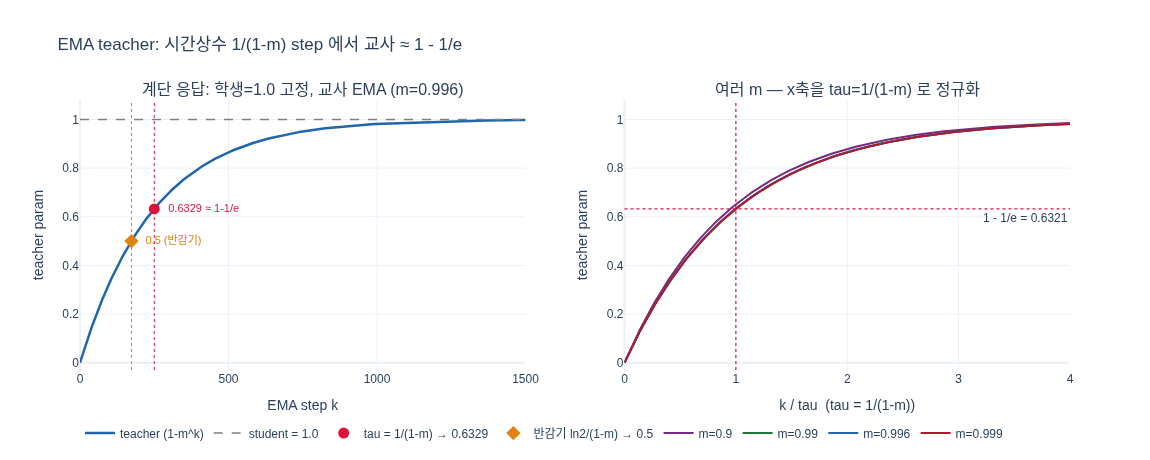

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/d79e00c8-a5c2-4b39-b377-95e20d377a77/expy.png


In [7]:
N = 1500
ks = np.arange(N + 1)
curve = 1 - m ** ks
half = math.log(2) / (1 - m)

print(f"tau  = {1/(1-m):.1f} step  → 교사 {1 - m**(1/(1-m)):.4f}")
print(f"t1/2 = {half:.1f} step  → 교사 {1 - m**half:.4f}")
print(f"3tau = {3/(1-m):.1f} step  → 교사 {1 - m**(3/(1-m)):.4f} (약 95%)")

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("계단 응답: 학생=1.0 고정, 교사 EMA (m=0.996)",
                    "여러 m — x축을 tau=1/(1-m) 로 정규화"),
)

fig.add_trace(go.Scatter(x=ks, y=curve, mode="lines", name="teacher (1-m^k)",
                         line=dict(color="#2166ac", width=2.5)), row=1, col=1)
fig.add_trace(go.Scatter(x=[0, N], y=[1, 1], mode="lines", name="student = 1.0",
                         line=dict(color="gray", dash="dash", width=1.5)), row=1, col=1)
fig.add_trace(go.Scatter(x=[T], y=[1 - 1/math.e], mode="markers+text",
                         name="tau = 1/(1-m) → 0.6329",
                         marker=dict(color="crimson", size=11, symbol="circle"),
                         text=["  0.6329 ≈ 1-1/e"], textposition="middle right",
                         textfont=dict(color="crimson", size=11)), row=1, col=1)
fig.add_trace(go.Scatter(x=[half], y=[0.5], mode="markers+text",
                         name="반감기 ln2/(1-m) → 0.5",
                         marker=dict(color="#e08214", size=11, symbol="diamond"),
                         text=["  0.5 (반감기)"], textposition="middle right",
                         textfont=dict(color="#e08214", size=11)), row=1, col=1)
fig.add_vline(x=T, line=dict(color="crimson", dash="dot", width=1), row=1, col=1)
fig.add_vline(x=half, line=dict(color="#e08214", dash="dot", width=1), row=1, col=1)

palette = {0.9: "#762a83", 0.99: "#1b7837", 0.996: "#2166ac", 0.999: "#b2182b"}
u = np.linspace(0, 4, 400)
for mm, color in palette.items():
    tau_m = 1 / (1 - mm)
    fig.add_trace(go.Scatter(x=u, y=1 - mm ** (u * tau_m), mode="lines",
                             name=f"m={mm}", line=dict(color=color, width=2),
                             showlegend=True), row=1, col=2)
fig.add_hline(y=1 - 1/math.e, line=dict(color="crimson", dash="dot", width=1.2),
              annotation_text="1 - 1/e = 0.6321", annotation_position="bottom right",
              row=1, col=2)
fig.add_vline(x=1, line=dict(color="crimson", dash="dot", width=1.2), row=1, col=2)

fig.update_xaxes(title_text="EMA step k", row=1, col=1)
fig.update_xaxes(title_text="k / tau  (tau = 1/(1-m))", row=1, col=2)
fig.update_yaxes(title_text="teacher param", range=[-0.03, 1.08], row=1, col=1)
fig.update_yaxes(title_text="teacher param", range=[-0.03, 1.08], row=1, col=2)
fig.update_layout(height=460, width=1150, template="plotly_white",
                  title_text="EMA teacher: 시간상수 1/(1-m) step 에서 교사 ≈ 1 - 1/e",
                  legend=dict(orientation="h", y=-0.18))

_show(fig)
png_path = os.path.join(HERE, "expy.png")
fig.write_image(png_path, scale=2)
print("saved:", png_path)

## 7. 보너스 — 학생이 움직이면 교사는 $\approx 1/(1-m)$ step 뒤처진다

계단이 아니라 학생이 **선형** 으로 움직인다고 하자: $\theta_s^{(k)} = a k$.
정상 상태에서 EMA는 같은 기울기 $a$ 로 따라가되 일정한 **지연(lag)** 을 갖는다.

$$
\theta_t^{(k)} \approx a\Bigl(k - \frac{m}{1-m}\Bigr)
\;\Longrightarrow\;
\text{지연} = \frac{m}{1-m} \approx \frac{1}{1-m}\ \text{step}
$$

이것이 "교사는 최근 $1/(1-m)$ iteration 의 학생을 평균한 모델" 이라는 말의 정확한 의미다.

In [8]:
a = 0.01
theta_t = 0.0
lags = []
for k in range(1, 4001):
    theta_s_k = a * k
    theta_t = m * theta_t + (1 - m) * theta_s_k
    if k % 1000 == 0:
        lag_steps = (theta_s_k - theta_t) / a      # 값 차이를 step 수로 환산
        lags.append((k, theta_s_k, theta_t, lag_steps))

print("  k    student   teacher   지연(step)")
for k, s, t, lg in lags:
    print(f"{k:>5}  {s:8.3f}  {t:8.3f}   {lg:8.2f}")
print(f"\n이론 지연 m/(1-m) = {m/(1-m):.2f} step,  1/(1-m) = {1/(1-m):.2f} step")

  k    student   teacher   지연(step)
 1000    10.000     7.555     244.48
 2000    20.000    17.511     248.92
 3000    30.000    27.510     249.00
 4000    40.000    37.510     249.00

이론 지연 m/(1-m) = 249.00 step,  1/(1-m) = 250.00 step


## 정리

| 항목 | 값 (m = 0.996) |
|---|---|
| 시간상수 $\tau = 1/(1-m)$ | 250 step |
| $\tau$ step 후 교사 값 | **0.6329** |
| 이론값 $1 - 1/e$ | 0.6321 |
| 반감기 $\ln 2/(1-m)$ | 173.3 step |
| 선형 추종 시 지연 $m/(1-m)$ | 249 step |

DINO에서 $m$ 은 0.996 → 1.0 으로 **증가** 하는 코사인 스케줄이라
학습이 진행될수록 $\tau$ 가 커지고 교사는 점점 얼어붙어 타겟이 안정화된다.